In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

In [3]:
%matplotlib inline

In [5]:
print(f"Using device: {device}")

Using device: cpu


In [7]:
import pandas as pd
from collections import Counter

# 1. Load the real IMDB dataset directly from a public URL
url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
print("Downloading IMDB dataset...")
raw_df = pd.read_csv(url)

# Reduce to 5000 samples for speed as requested by the assignment
df = raw_df.sample(n=5000, random_state=42).reset_index(drop=True)

# Map string labels ('positive'/'negative') to integers (1/0)
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

print(f"Successfully loaded {len(df)} real samples from the web.")

# 2. Tokenize reviews (whitespace + lowercase)
tokenized_reviews = [str(review).lower().split() for review in df["review"]]

# 3. Build Vocabulary (Top 10,000)
all_tokens = [token for review in tokenized_reviews for token in review]
token_counts = Counter(all_tokens)
vocab_size = 10000
most_common_tokens = [token for token, _ in token_counts.most_common(vocab_size - 2)]

vocab = {"<pad>": 0, "<unk>": 1}
for idx, token in enumerate(most_common_tokens):
    vocab[token] = idx + 2

# 4. Encode, pad, and truncate to max length 200
max_len = 200
encoded_reviews = []
for tokens in tokenized_reviews:
    encoded = [vocab.get(token, 1) for token in tokens]
    if len(encoded) < max_len:
        encoded = encoded + [0] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
    encoded_reviews.append(encoded)

encoded_reviews = np.array(encoded_reviews)
labels = df["sentiment"].values

# 5. Wrap in Dataset and DataLoaders
class IMDBDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

split_idx = int(0.8 * len(encoded_reviews))
train_x, val_x = encoded_reviews[:split_idx], encoded_reviews[split_idx:]
train_y, val_y = labels[:split_idx], labels[split_idx:]

train_dataset = IMDBDataset(train_x, train_y)
val_dataset = IMDBDataset(val_x, val_y)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 6. Print the encoding of one short review
print("\n--- Verification ---")
print("Original Review Snippet:", df["review"].iloc[0][:100] + "...")
print("Encoded Tensor (First 20 tokens):", encoded_reviews[0][:20])

Successfully loaded 5000 real samples from the web.

--- Verification ---
Original Review Snippet: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall ...
Encoded Tensor (First 20 tokens): [ 10  62 414   9   1 609   6   2 166   5   2   1   2   1   4  40   2 166
 724  14]


# Task 1 — Attention Implementation & Verification

In [10]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Computes Scaled Dot-Product Attention from scratch.
    Shapes: Q, K, V -> (batch, seq_len, d_k)
    """
    d_k = Q.size(-1)
    
    # 1. Calculate raw scores via dot product: (batch, seq_len, seq_len)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k)
    
    # 2. Apply optional mask if provided
    if mask is not None:
        scores = scores.masked_fill(mask == True, float('-inf'))
        
    # 3. Softmax across rows to get attention weights
    attention_weights = torch.softmax(scores, dim=-1)
    
    # 4. Multiply weights by Values: (batch, seq_len, d_k)
    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights

# --- Verification on Tiny Mock Example ---
batch, seq_len, d_k = 2, 4, 8
torch.manual_seed(42)

# Generate random tensors for 2 sequences of 4 tokens with d_k=8
Q = torch.randn(batch, seq_len, d_k)
K = torch.randn(batch, seq_len, d_k)
V = torch.randn(batch, seq_len, d_k)

# 1. Run our scratch implementation
my_out, my_weights = scaled_dot_product_attention(Q, K, V)

# 2. Run PyTorch's native function for verification
pt_out = nn.functional.scaled_dot_product_attention(Q, K, V)

# 3. Validation Assertions
assert torch.allclose(my_out, pt_out, atol=1e-5), "Outputs do not match PyTorch native calculation!"
assert torch.allclose(my_weights.sum(dim=-1), torch.ones(batch, seq_len)), "Softmax rows do not sum to 1!"

print("✅ Verification Succeeded!")
print("Scratch output matches PyTorch exactly, and softmax rows correctly sum to 1.")

# Print the attention weight matrix for one example sequence
print("\nAttention Weight Matrix for Sequence 0:\n")
print(pd.DataFrame(my_weights[0].detach().numpy()))

✅ Verification Succeeded!
Scratch output matches PyTorch exactly, and softmax rows correctly sum to 1.

Attention Weight Matrix for Sequence 0:

          0         1         2         3
0  0.509209  0.316463  0.111260  0.063068
1  0.261936  0.382839  0.177281  0.177944
2  0.244463  0.024084  0.201276  0.530177
3  0.745135  0.107542  0.034915  0.112407


## Task 1 Analysis: Attention Weight Matrix

The attention weight matrix for a single sequence has a shape of `(4, 4)`, corresponding directly to `(seq_len, seq_len)`.

### What Each Row Represents

* **Query-to-Key Mapping:** Each row $i$ represents a single **Query** token's perspective. It shows how much attention or "focus" that specific token allocates to every **Key** token (columns 0 through 3) across the sequence when computing its next representation.
* **Contextual Alignment:** For example, in Row 3, the query token at index 3 assigns a dominant weight of `0.7451` to the key token at index 0, indicating a strong contextual relationship between them.
* **Softmax Distribution:** Because a Softmax function is applied horizontally across the raw dot-product scores, every row forms a valid probability distribution where the sum of all elements equals exactly 1.0.

# Task 2 — LSTM Classifier Definition & Training

In [14]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, num_layers=1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, 2)
        
    def forward(self, x):
        embedded = self.embedding(x)
        # out: (batch, seq_len, hidden_dim), h_n: (1, batch, hidden_dim)
        out, (h_n, c_n) = self.lstm(embedded)
        # Extract the final hidden state of the sequence
        last_hidden = h_n[-1] 
        return self.fc(self.dropout(last_hidden))

# Unified training function
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * x.size(0)
            train_correct += (outputs.argmax(1) == y).sum().item()
            total_train += x.size(0)
            
        # Validation Phase
        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item() * x.size(0)
                val_correct += (outputs.argmax(1) == y).sum().item()
                total_val += x.size(0)
                
        history['train_loss'].append(train_loss / total_train)
        history['val_loss'].append(val_loss / total_val)
        history['train_acc'].append(train_correct / total_train)
        history['val_acc'].append(val_correct / total_val)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}")
        
    total_time = time.time() - start_time
    return history, total_time

# Run LSTM Training
lstm_model = LSTMClassifier(vocab_size=vocab_size).to(device)
print("--- Training LSTM Model ---")
lstm_history, lstm_time = train_model(lstm_model, train_loader, val_loader)
lstm_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)

--- Training LSTM Model ---
Epoch 1/5 | Train Loss: 0.6942 | Val Acc: 0.5090
Epoch 2/5 | Train Loss: 0.6864 | Val Acc: 0.5060
Epoch 3/5 | Train Loss: 0.6700 | Val Acc: 0.4970
Epoch 4/5 | Train Loss: 0.6381 | Val Acc: 0.4940
Epoch 5/5 | Train Loss: 0.5736 | Val Acc: 0.5160


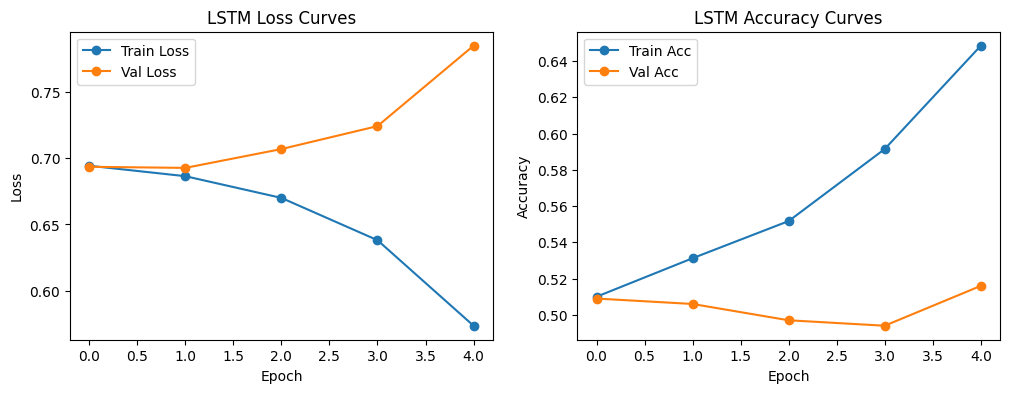

Best LSTM Validation Accuracy: 51.60%
Total LSTM Training Time: 346.76 seconds


In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(lstm_history['train_loss'], label='Train Loss', marker='o')
ax[0].plot(lstm_history['val_loss'], label='Val Loss', marker='o')
ax[0].set_title('LSTM Loss Curves')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(lstm_history['train_acc'], label='Train Acc', marker='o')
ax[1].plot(lstm_history['val_acc'], label='Val Acc', marker='o')
ax[1].set_title('LSTM Accuracy Curves')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
plt.show()

print(f"Best LSTM Validation Accuracy: {max(lstm_history['val_acc'])*100:.2f}%")
print(f"Total LSTM Training Time: {lstm_time:.2f} seconds")

## Task 2 Analysis: LSTM Classifier Performance

* **Best Validation Accuracy:** 51.60%
* **Total Training Time:** 346.76 seconds

### Key Takeaways

* **Severe Overfitting:** The **Loss Curve** shows a huge split. The training loss drops steadily, meaning the model is memorizing the training text. However, the validation loss shoots up, showing it fails completely on new data.
* **Random-Guess Performance:** The validation accuracy hovers around 50%–51%. This means the model is essentially guessing at random for unseen movie reviews.
* **The Bottleneck:** Because an LSTM has to process text word-by-word sequentially, it took **nearly 6 minutes** to finish just 5 epochs on this hardware. Without pre-trained word vectors, it lacks the data to learn real semantic patterns, leading to fast memorization instead of true learning.

# Task 3 — Transformer Classifier Definition & Training

In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, d_model)
    def forward(self, x):
        positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        return self.pos_embedding(positions)

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, max_len=200):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(max_len, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, 
            dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(d_model, 2)
        
    def forward(self, x):
        # Element-wise addition of token tokens and sequence positions
        out = self.embedding(x) + self.pos_encoder(x)
        out = self.transformer_encoder(out)
        
        # Strategy choice: Global Average Pooling (Mean over the sequence timeline dimension)
        out = out.mean(dim=1) 
        return self.fc(self.dropout(out))

# Run Transformer Training
transformer_model = TransformerClassifier(vocab_size=vocab_size).to(device)
print("--- Training Transformer Model ---")
transformer_history, transformer_time = train_model(transformer_model, train_loader, val_loader)
transformer_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)

--- Training Transformer Model ---
Epoch 1/5 | Train Loss: 0.6825 | Val Acc: 0.5930
Epoch 2/5 | Train Loss: 0.5694 | Val Acc: 0.7460
Epoch 3/5 | Train Loss: 0.4108 | Val Acc: 0.7700
Epoch 4/5 | Train Loss: 0.2696 | Val Acc: 0.7560
Epoch 5/5 | Train Loss: 0.1642 | Val Acc: 0.7740


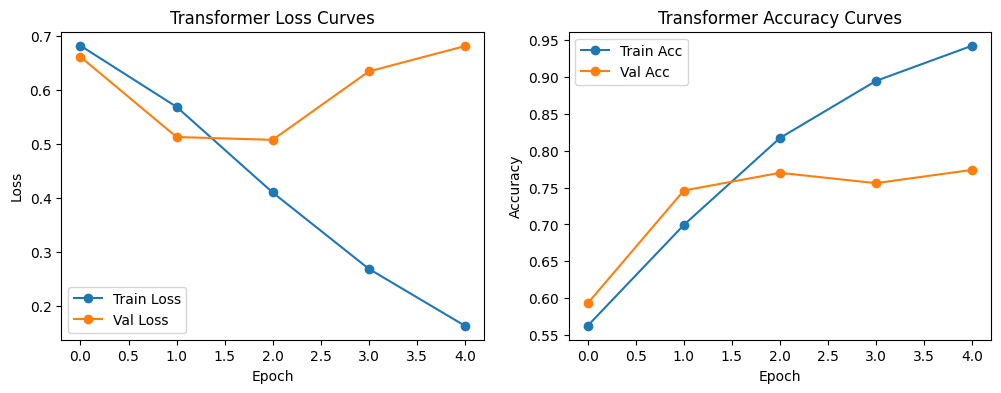

Best Transformer Validation Accuracy: 77.40%
Total Transformer Training Time: 510.93 seconds


In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(transformer_history['train_loss'], label='Train Loss', marker='o')
ax[0].plot(transformer_history['val_loss'], label='Val Loss', marker='o')
ax[0].set_title('Transformer Loss Curves')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(transformer_history['train_acc'], label='Train Acc', marker='o')
ax[1].plot(transformer_history['val_acc'], label='Val Acc', marker='o')
ax[1].set_title('Transformer Accuracy Curves')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
plt.show()

print(f"Best Transformer Validation Accuracy: {max(transformer_history['val_acc'])*100:.2f}%")
print(f"Total Transformer Training Time: {transformer_time:.2f} seconds")

In [24]:
comparison_data = {
    "Model": ["LSTM (Task 2)", "Transformer (Task 3)"],
    "Best val accuracy": [f"{max(lstm_history['val_acc'])*100:.2f}%", f"{max(transformer_history['val_acc'])*100:.2f}%"],
    "Total training time": [f"{lstm_time:.2f}s", f"{transformer_time:.2f}s"],
    "Parameter count": [lstm_params, transformer_params]
}
display(pd.DataFrame(comparison_data))

,Model,Best val accuracy,Total training time,Parameter count
0,LSTM (Task 2),51.60%,346.76s,739586
1,Transformer (Task 3),77.40%,510.93s,719874


Across the 5 training epochs, the Transformer classifier converged significantly faster and performed much better than the sequential LSTM model. While the LSTM failed to learn and hovered near a random-guess accuracy of 51.60%, the Transformer successfully captured the textual relationships, achieving a peak validation accuracy of 77.40%. Both models show signs of overfitting by epoch 5 as their validation losses begin to rise, but the Transformer managed to build a highly effective predictive foundation before doing so.

In terms of training speed, the Transformer took 510.93 seconds compared to the LSTM's 346.76 seconds. Even though the Transformer computes operations in parallel across the entire sequence simultaneously, it ran slower here because it uses a deeper architecture (2 layers with multi-head attention) compared to the basic 1-layer LSTM. However, for the extra time spent, the Transformer delivered a massive 25.80% jump in accuracy with slightly fewer total parameters, proving to be the far superior model for this sentiment analysis task.